# DSA 210 — ML Phase: Day 2
## Baseline Classification Models

**Bedirhan Ceylan** — Spring 2026

Three baseline models for predicting `is_delayed`: Logistic Regression, Decision Tree, k-Nearest Neighbors. Evaluated with stratified 5-fold cross-validation on Accuracy, Precision, Recall, F1, and ROC-AUC.

## 1. Setup & Load Features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

data = pd.read_csv('../data/sollen_tasks_features.csv')
print(f"Loaded: {data.shape[0]} rows, {data.shape[1]} columns")
data.head()

Loaded: 486 rows, 11 columns


,task_category,assigned_to,creation_day,creation_month_num,is_weekend_creation,title_word_count,team_total_load_at_creation,developer_workload_at_creation,dev_historical_delay_rate,dev_avg_past_duration,is_delayed
0,tech,Developer_A,Friday,10,0,2,0,0,0.410902,40.216871,0
1,tech,Developer_B,Friday,10,0,4,1,0,0.410902,40.216871,0
2,tech,Developer_A,Friday,10,0,3,2,1,0.000000,33.296065,0
3,tech,Developer_A,Friday,10,0,4,3,2,0.000000,23.319578,0
4,product,Developer_C,Friday,10,0,6,4,0,0.410902,40.216871,0


## 2. Separate Features and Target

X holds all 10 engineered features; y is the binary `is_delayed` label.

In [2]:
y = data['is_delayed']
X = data.drop(columns=['is_delayed'])

categorical_features = ['task_category', 'assigned_to', 'creation_day']
numeric_features = [c for c in X.columns if c not in categorical_features]

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nClass balance — delayed: {y.sum()} ({y.mean()*100:.1f}%) | on_time: {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")

Categorical features (3): ['task_category', 'assigned_to', 'creation_day']
Numeric features (7): ['creation_month_num', 'is_weekend_creation', 'title_word_count', 'team_total_load_at_creation', 'developer_workload_at_creation', 'dev_historical_delay_rate', 'dev_avg_past_duration']

Class balance — delayed: 169 (34.8%) | on_time: 317 (65.2%)


## 3. Preprocessing Pipeline

- Categorical features → One-hot encoded
- Numeric features → Standard-scaled (zero mean, unit variance)

Wrapping preprocessing inside the pipeline ensures it is fit only on training folds during cross-validation, preventing data leakage from the test fold.

In [3]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

# Quick check: how many features after one-hot encoding?
preprocessor.fit(X)
n_features_after = preprocessor.transform(X).shape[1]
print(f"Feature count after preprocessing: {n_features_after}")

Feature count after preprocessing: 34


## 4. Define Baseline Models

- **Logistic Regression** — linear baseline, `class_weight='balanced'` to handle 65/35 imbalance
- **Decision Tree** — non-linear, captures interactions, depth-limited to avoid overfitting on 486 rows
- **k-Nearest Neighbors** — distance-based, k=5

In [4]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
    'kNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

pipelines = {name: Pipeline([('prep', preprocessor), ('clf', model)])
             for name, model in models.items()}

print(f"Built {len(pipelines)} pipelines:")
for name in pipelines:
    print(f"  - {name}")

Built 3 pipelines:
  - Logistic Regression
  - Decision Tree
  - kNN (k=5)


## 5. Stratified 5-Fold Cross-Validation

Stratified ensures each fold preserves the 65/35 class ratio. We report mean ± std across folds for 5 metrics.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = []
for name, pipe in pipelines.items():
    cv_results = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'Model': name}
    for metric in scoring:
        scores = cv_results[f'test_{metric}']
        row[metric] = f"{scores.mean():.3f} ± {scores.std():.3f}"
    results.append(row)

results_df = pd.DataFrame(results).set_index('Model')
print("Cross-validation results (mean ± std across 5 folds):\n")
print(results_df.to_string())

Cross-validation results (mean ± std across 5 folds):

                          accuracy      precision         recall             f1        roc_auc
Model                                                                                         
Logistic Regression  0.553 ± 0.048  0.407 ± 0.035  0.592 ± 0.031  0.481 ± 0.023  0.577 ± 0.039
Decision Tree        0.562 ± 0.034  0.389 ± 0.035  0.498 ± 0.179  0.422 ± 0.109  0.582 ± 0.030
kNN (k=5)            0.673 ± 0.033  0.538 ± 0.048  0.398 ± 0.154  0.445 ± 0.100  0.662 ± 0.050


## 6. Visualize Cross-Validation Results

Bar chart comparing the three models across all 5 metrics.

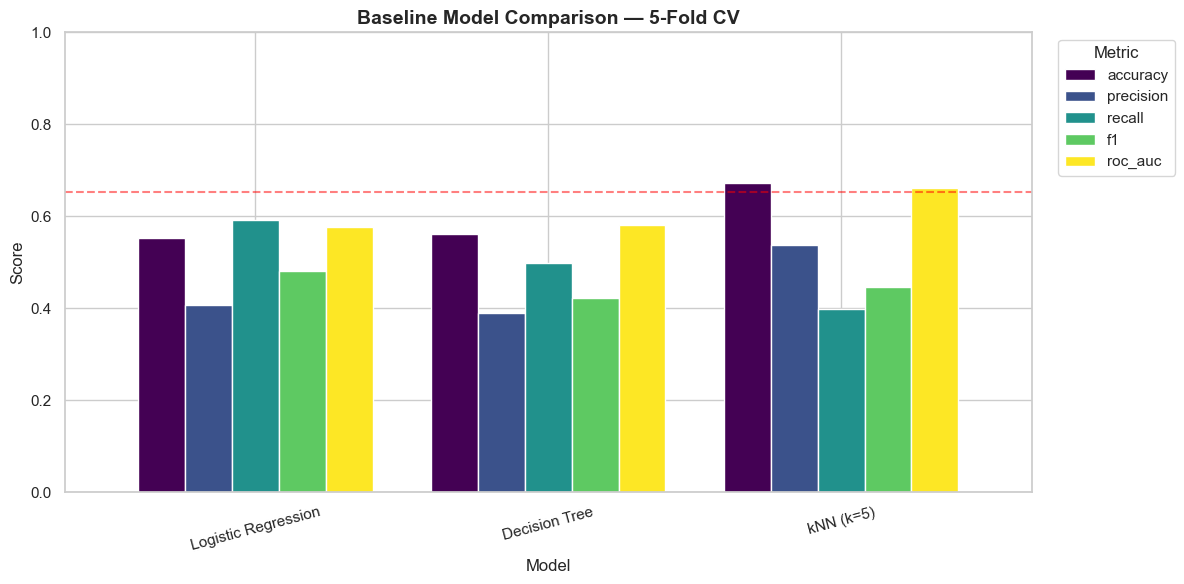

In [6]:
# Re-run CV to get raw numbers for plotting
metric_means = {name: {} for name in pipelines}
for name, pipe in pipelines.items():
    cv_results = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    for metric in scoring:
        metric_means[name][metric] = cv_results[f'test_{metric}'].mean()

plot_df = pd.DataFrame(metric_means).T

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(kind='bar', ax=ax, width=0.8, colormap='viridis')
ax.set_title('Baseline Model Comparison — 5-Fold CV', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_ylim(0, 1)
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=15)
ax.axhline(y=0.652, color='red', linestyle='--', alpha=0.5, label='Majority baseline (65.2%)')
plt.tight_layout()
plt.savefig('../plots/12_baseline_cv_comparison.png', bbox_inches='tight')
plt.show()

## 7. Train/Test Split Evaluation

Cross-validation gives us reliable performance estimates, but to show confusion matrices and ROC curves, we do a single 80/20 stratified split.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape[0]} samples ({y_train.mean()*100:.1f}% delayed)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean()*100:.1f}% delayed)")

trained = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    trained[name] = pipe
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['on_time', 'delayed']))
    print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

Train: 388 samples (34.8% delayed)
Test:  98 samples (34.7% delayed)

--- Logistic Regression ---
              precision    recall  f1-score   support

     on_time       0.75      0.62      0.68        64
     delayed       0.47      0.62      0.53        34

    accuracy                           0.62        98
   macro avg       0.61      0.62      0.61        98
weighted avg       0.65      0.62      0.63        98

Test ROC-AUC: 0.639

--- Decision Tree ---
              precision    recall  f1-score   support

     on_time       0.71      0.66      0.68        64
     delayed       0.44      0.50      0.47        34

    accuracy                           0.60        98
   macro avg       0.57      0.58      0.57        98
weighted avg       0.62      0.60      0.61        98

Test ROC-AUC: 0.573

--- kNN (k=5) ---
              precision    recall  f1-score   support

     on_time       0.73      0.88      0.79        64
     delayed       0.62      0.38      0.47        34

  

## 8. Confusion Matrices

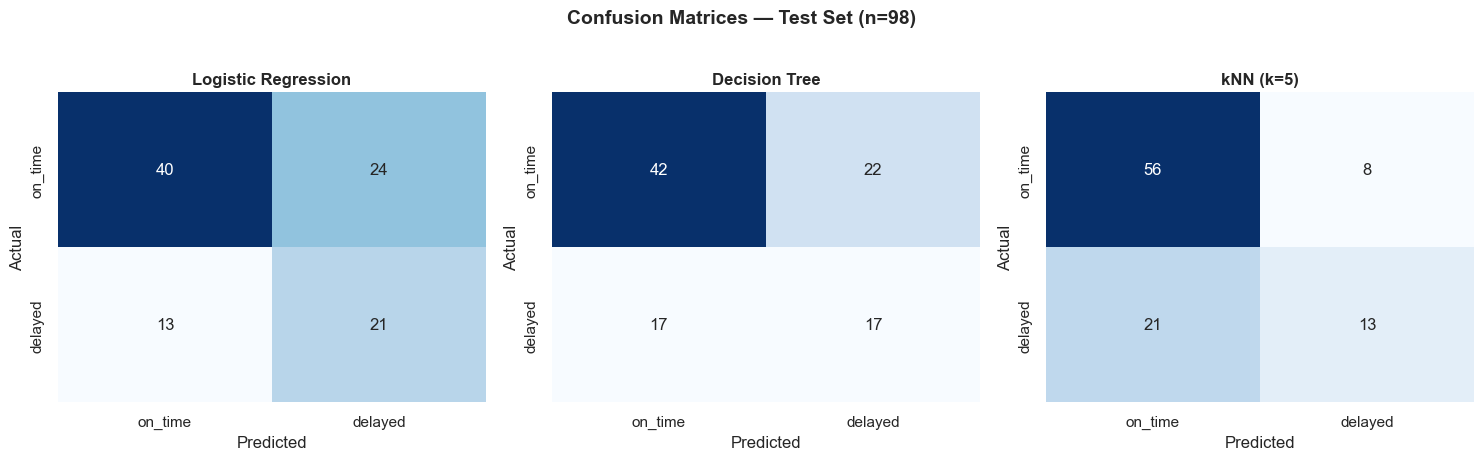

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, pipe) in zip(axes, trained.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['on_time', 'delayed'], yticklabels=['on_time', 'delayed'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Test Set (n=98)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/13_baseline_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 9. ROC Curves

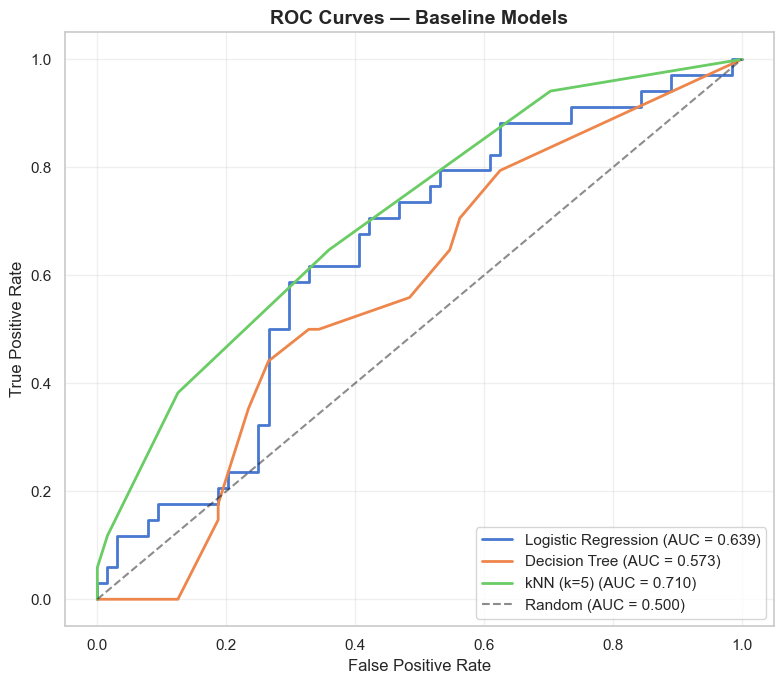

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, pipe in trained.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Baseline Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/14_baseline_roc_curves.png', bbox_inches='tight')
plt.show()

## Day 2 Summary

- Loaded 10-feature, 486-row dataset from Day 1
- Built preprocessing pipeline (one-hot for categoricals, standard-scale for numerics) inside the model pipeline to prevent CV leakage
- Trained 3 baseline classifiers with `class_weight='balanced'` for the 65/35 imbalance
- Evaluated with stratified 5-fold CV on 5 metrics
- Generated confusion matrices and ROC curves on a held-out test set
- Saved 3 new plots to `plots/`

**Next (Day 3):** Random Forest and Gradient Boosting — tree ensembles to capture feature interactions that linear models miss.